In [1]:
import pandas as pd

titles = pd.read_csv("titles.csv")
credits = pd.read_csv("credits.csv")

print("Titles dataset:")
display(titles.head())

print("Credits dataset:")
display(credits.head())

Titles dataset:


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


Credits dataset:


,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR
2,7064,tm84618,Albert Brooks,Tom,ACTOR
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR


In [2]:
print("Titles shape:", titles.shape)
print("Credits shape:", credits.shape)

print("\nTitles columns:")
print(titles.columns.tolist())

print("\nCredits columns:")
print(credits.columns.tolist())

Titles shape: (5850, 15)
Credits shape: (77801, 5)

Titles columns:
['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

Credits columns:
['person_id', 'id', 'name', 'character', 'role']


In [3]:
print("Missing values in Titles:")
print(titles.isnull().sum())

print("\nMissing values in Credits:")
print(credits.isnull().sum())

Missing values in Titles:
id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2619
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                  403
imdb_score               482
imdb_votes               498
tmdb_popularity           91
tmdb_score               311
dtype: int64

Missing values in Credits:
person_id       0
id              0
name            0
character    9772
role            0
dtype: int64


In [4]:
print(titles["type"].value_counts())

type
MOVIE    3744
SHOW     2106
Name: count, dtype: int64


In [5]:
print(titles["genres"].value_counts().head(10))


genres
['comedy']                        484
['documentation']                 329
['drama']                         328
['comedy', 'drama']               135
['drama', 'romance']              124
['reality']                       113
['drama', 'comedy']               109
['comedy', 'documentation']       104
['comedy', 'romance']              69
['comedy', 'drama', 'romance']     67
Name: count, dtype: int64


In [6]:
genre_counts = titles.explode("genres")["genres"].value_counts()

print(genre_counts.head(10))

genres
['comedy']                        484
['documentation']                 329
['drama']                         328
['comedy', 'drama']               135
['drama', 'romance']              124
['reality']                       113
['drama', 'comedy']               109
['comedy', 'documentation']       104
['comedy', 'romance']              69
['comedy', 'drama', 'romance']     67
Name: count, dtype: int64


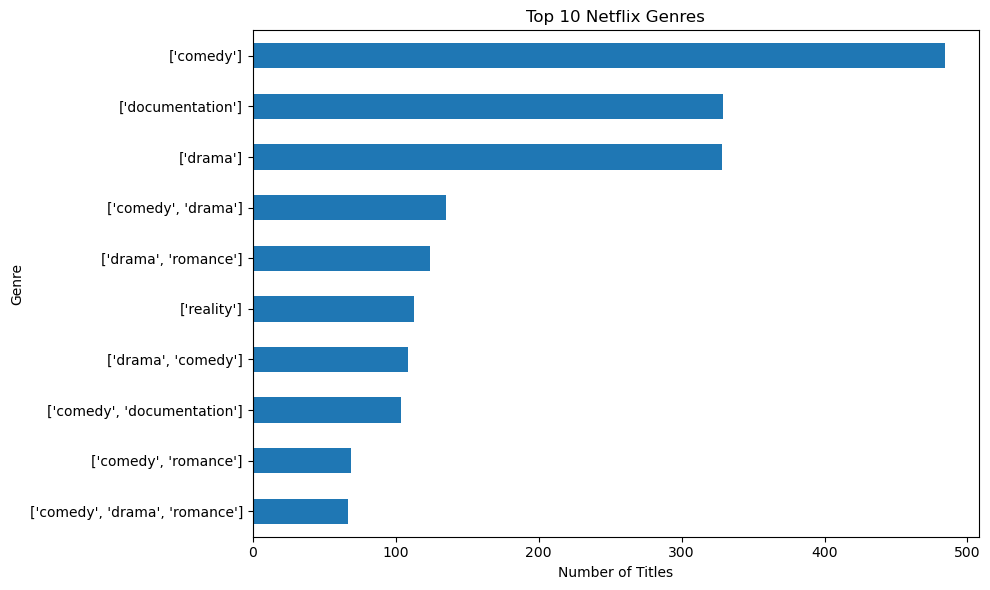

In [7]:
import matplotlib.pyplot as plt

top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))
top_genres.sort_values().plot(kind="barh")

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

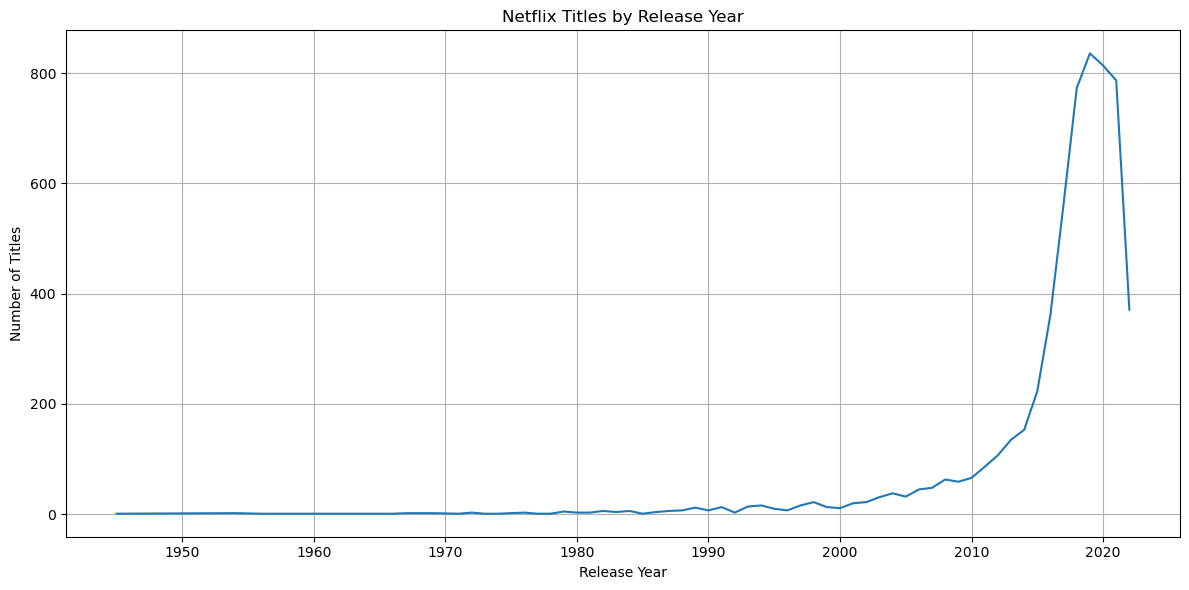

In [8]:
year_counts = titles["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
year_counts.plot()

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.tight_layout()
plt.show()

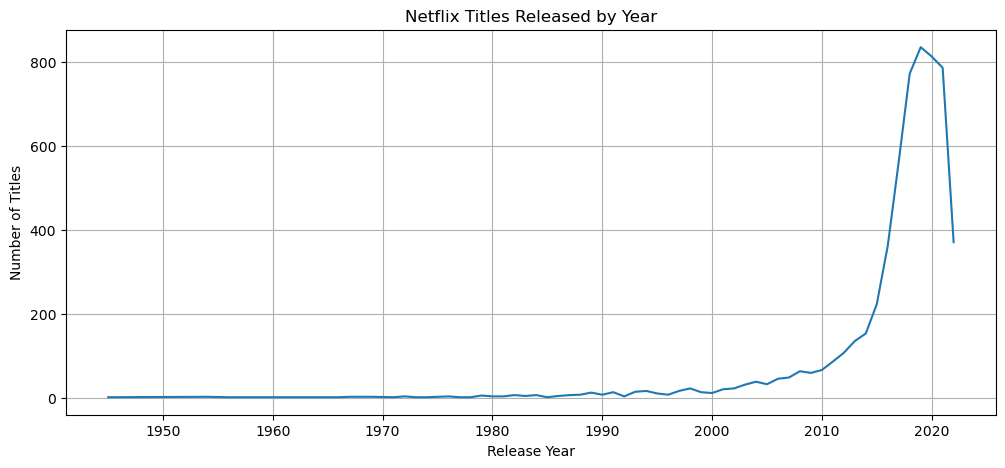

In [9]:
# Netflix titles by release year

year_counts = titles['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values)
plt.title('Netflix Titles Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

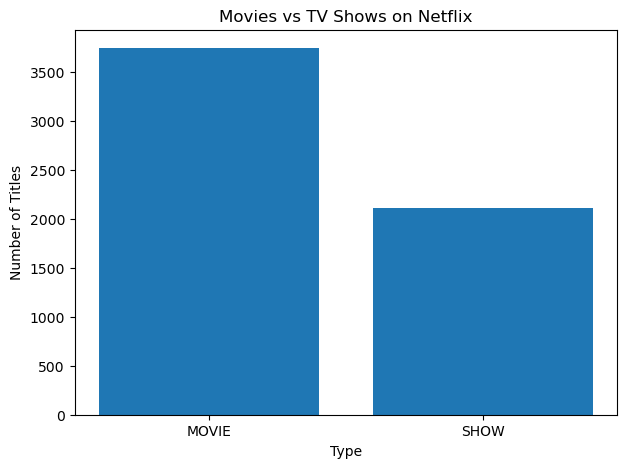

In [10]:
# Movies vs TV Shows

type_counts = titles['type'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(type_counts.index, type_counts.values)
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Number of Titles')
plt.show()

In [11]:
# Top 10 countries producing Netflix content

country_counts = titles['country'].dropna().str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(country_counts.index[::-1], country_counts.values[::-1])
plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

KeyError: 'country'

In [12]:
titles['country'].head()

KeyError: 'country'

In [13]:
print(titles.columns)

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')


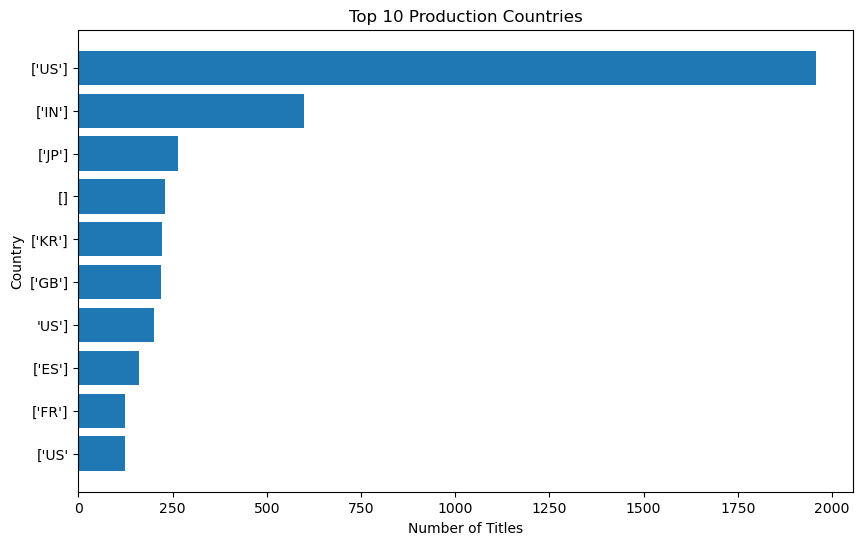

In [14]:
# Top 10 countries producing Netflix content

country_counts = (
    titles['production_countries']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(country_counts.index[::-1], country_counts.values[::-1])
plt.title('Top 10 Production Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

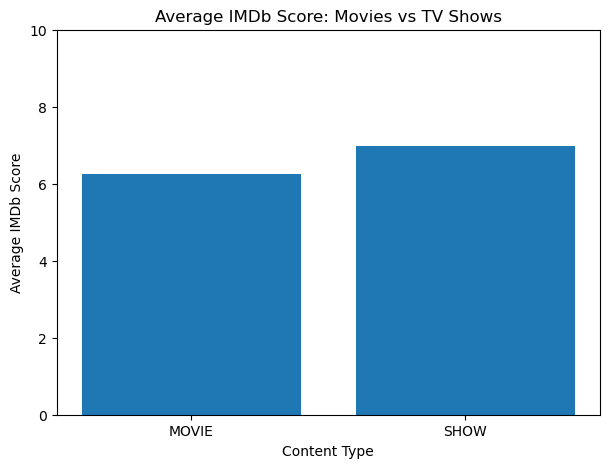

In [15]:
# Average IMDb Score by Content Type

avg_score = titles.groupby('type')['imdb_score'].mean()

plt.figure(figsize=(7, 5))
plt.bar(avg_score.index, avg_score.values)
plt.title('Average IMDb Score: Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Average IMDb Score')
plt.ylim(0, 10)
plt.show()

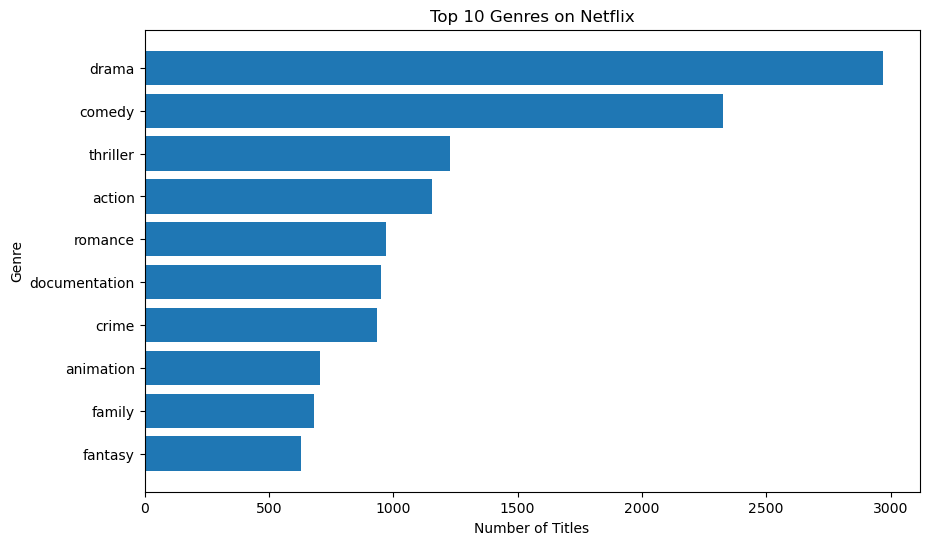

In [16]:
# Top 10 Genres on Netflix

genre_counts = (
    titles['genres']
    .dropna()
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(genre_counts.index[::-1], genre_counts.values[::-1])
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()